In [1]:
#by Henry Schumacher
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import time
start_setup = time.process_time_ns()
print('---------------------------------------')
print(time.strftime("PLSmethods.ipynb started: %a, %d %b %Y %H:%M:%S", time.localtime()))
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import os
import sys
import json
import uuid
import h5py
import math
import tqdm
import xraydb
import plotly
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import numpy as np
import pandas as pd
# import pyxray as xy
import odrpack as odr
import seaborn as sb
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from scipy.ndimage import median_filter
from pybaselines import Baseline
from sklearn.metrics import root_mean_squared_error
from getmac import get_mac_address as gma
from itertools import chain
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
from colors import load_colors
from functions_pixe import *
from polygauss import *
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})


plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": "\n".join([
          r'\usepackage{amsmath}',
     ]),
})

#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
color_schemes = load_colors()


end_setup = time.process_time_ns()
elapsed_setup = (end_setup - start_setup)/1e6

print(f'INFO: SETUP COMPLETE ({elapsed_setup:.4f} ms)')
print('---------------------------------------')
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

---------------------------------------
PLSmethods.ipynb started: Tue, 16 Jun 2026 10:44:49
INFO: SETUP COMPLETE (1312.5000 ms)
---------------------------------------


In [19]:
filepath = './simulation/toy_model_run_150626_232426.json'
simulation_data = read_json_formatted_file(filepath)



In [20]:
def signal_to_noise(signal, noise):
    P_signal = np.mean(np.array(signal)**2)
    P_noise = np.mean(np.array(noise)**2)
    snr = 10*np.log10(P_signal/P_noise)
    
    print(f'Signal-To-Noise Ration SNR = {snr:.2f}.')
    
    return snr 

### simulation_data structure

simulation_data[ i ][ j ][ keys ]

- i: number of experiments: = len(simulation_data) = 100 for most
- j: 
  - 0: toy model data
  - 1: PLS method data
- keys:
  - if j = 0: 'Bins', 'NumberOfPeaks', 'SNR', 'GaussianPeaks', 'Noise', 'BaselineType', 'BaselineParameter', 'Baseline', 'SyntheticData'
  - if j = 1: 'arpls_lambda', 'arpls_rmse', 'aspls_lambda', 'aspls_rmse' (each optimal parameters for given toy model)

In [21]:
print(simulation_data[1][1].keys())

dict_keys(['arpls_lambda', 'arpls_rmse', 'aspls_lambda', 'aspls_rmse'])


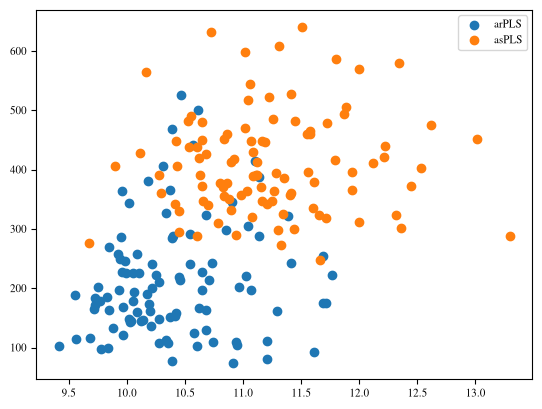

In [23]:
plt.figure()
plt.scatter([item[1]['arpls_lambda'] for item in simulation_data], [item[1]['arpls_rmse'] for item in simulation_data], label='arPLS')
plt.scatter([item[1]['aspls_lambda'] for item in simulation_data], [item[1]['aspls_rmse'] for item in simulation_data], label='asPLS')
plt.legend()
